# 🔹 Objective 1 — RFP-to-SKU Hybrid Matching Engine (Fixed & Complete)

## Dataset to Use
| File | Role | Columns Used |
|---|---|---|
| `product_catalog.csv` | SKU catalog — the items to match against | `sku_id`, `product_name`, `voltage_rating`, `conductor_material`, `insulation_type`, `sheath_type`, `temperature_rating`, `fire_resistance`, `armouring`, `core_count`, `size_sqmm`, `standards_complied` |
| `rfp_specs_7000.csv` | RFP specs — the query side (**use the CLEAN base dataset**) | `rfp_id`, `spec_text_raw`, `voltage_rating`, `conductor_material`, `insulation_type`, `sheath_type`, `temperature_rating`, `fire_resistance`, `armouring`, `core_count`, `size_sqmm`, `standards_required` |

> **Why the clean dataset?**  
> Objective 1 establishes the baseline system. The noisy variants (in-domain, out-of-domain, long-doc, positional shift, missing specs, numeric perturbation, unit variation) are reserved for **Objective 2** — robustness evaluation. Using a noisy variant here would conflate baseline quality with noise sensitivity.

## Fixes Applied Over Original Notebook
1. **Circular ground-truth bias** — original derived ground truth from Structured Score itself, making Structured-only trivially score 1.0. Fixed: ground truth is built from a **multi-signal composite** (struct + standards + name-overlap), not from a single component.
2. **O(N×M) row-by-row loop** — original called `cosine_similarity` per pair inside a Python loop (200k calls). Fixed: vectorised matrix multiply for all semantic scores in one shot.
3. **Structured score equally weights all fields** — original gave equal weight to `armouring` and `voltage_rating`. Fixed: **mandatory_specs-aware weighting** — fields flagged as mandatory in the RFP carry 2× weight.
4. **Flat numeric tolerance** — original used 10% tolerance equally for `core_count` (discrete, no tolerance acceptable) and `size_sqmm`. Fixed: `core_count` requires exact match; `size_sqmm` uses ±1 standard cable step tolerance.
5. **Standards matching too strict** — original required exact substring. Fixed: bidirectional partial match (either side contained in the other).
6. **Ablation only tested 4 hardcoded configs** — original skipped the full grid. Fixed: full 66-combination grid on 0.1 steps.
7. **`calculate_metrics` iterated over DataFrame per RFP** — O(N²) lookup. Fixed: pre-grouped NumPy arrays for all metric computation.
8. **Compliance_% could exceed 100** — float arithmetic artifact. Fixed: clipped to [0, 100].
9. **No reproducibility seed** — fixed.
10. **Duplicate code** — cells 0 and 22 were identical re-runs. Removed.

In [ ]:
# ============================================================
# CELL 1 — INSTALL DEPENDENCIES  (run once on fresh Colab)
# ============================================================
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib

In [ ]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import time
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)

print("✅ Imports done.")

✅ Imports done.


In [ ]:
# ============================================================
# CELL 3 — LOAD DATASETS
# ============================================================
# ── Upload these two files to Colab before running ──────────
#   1. product_catalog.csv      (200 rows × 16 cols)
#   2. rfp_specs_7000.csv       (7000 rows × 17 cols)  ← CLEAN base dataset
# ────────────────────────────────────────────────────────────

product_df = pd.read_csv("product_catalog.csv")
rfp_df     = pd.read_csv("rfp_specs_7000.csv")

# Strip whitespace from column names
product_df.columns = product_df.columns.str.strip()
rfp_df.columns     = rfp_df.columns.str.strip()

print(f"Product catalog : {product_df.shape}")
print(f"RFP specs       : {rfp_df.shape}")
print("\nProduct columns :", product_df.columns.tolist())
print("RFP columns     :", rfp_df.columns.tolist())

Product catalog : (200, 16)
RFP specs       : (7000, 17)

Product columns : ['sku_id', 'product_name', 'manufacturer', 'category', 'voltage_rating', 'conductor_material', 'core_count', 'size_sqmm', 'insulation_type', 'sheath_type', 'temperature_rating', 'fire_resistance', 'armouring', 'standards_complied', 'price_per_unit', 'lead_time_days']
RFP columns     : ['rfp_id', 'item_id', 'item_name', 'item_category', 'voltage_rating', 'conductor_material', 'core_count', 'size_sqmm', 'insulation_type', 'sheath_type', 'temperature_rating', 'fire_resistance', 'armouring', 'standards_required', 'mandatory_specs', 'tolerance_allowed', 'spec_text_raw']


In [ ]:
# ============================================================
# CELL 4 — STRUCTURED ATTRIBUTE SCORE  (FIX 3 + FIX 4)
#
# Changes vs original:
#   • Fields listed in mandatory_specs carry 2× weight
#   • core_count → exact match only (no tolerance)
#   • size_sqmm  → ±1 standard cable step (next/prev on IS/IEC ladder)
#     rather than a flat 10% band
# ============================================================

# Standard cable conductor size ladder (IS/IEC)
_SIZE_LADDER = [
    0.5, 0.75, 1.0, 1.5, 2.5, 4.0, 6.0, 10.0, 16.0,
    25.0, 35.0, 50.0, 70.0, 95.0, 120.0, 150.0, 185.0,
    240.0, 300.0, 400.0, 500.0, 630.0, 800.0, 1000.0
]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val: float) -> set:
    """Return val itself plus its immediate neighbours on the cable size ladder."""
    if val not in _SIZE_SET:
        # snap to nearest then get neighbours
        val = min(_SIZE_LADDER, key=lambda x: abs(x - val))
    idx = _SIZE_LADDER.index(val)
    neighbours = {val}
    if idx > 0:
        neighbours.add(_SIZE_LADDER[idx - 1])
    if idx < len(_SIZE_LADDER) - 1:
        neighbours.add(_SIZE_LADDER[idx + 1])
    return neighbours


def structured_score(rfp_row: pd.Series, sku_row: pd.Series) -> float:
    """
    Compute a weighted structured attribute match score in [0, 1].

    Weighting:
      • Fields listed in rfp_row['mandatory_specs'] → weight 2
      • All other fields → weight 1

    Numeric rules:
      • core_count : exact integer match required
      • size_sqmm  : accept if SKU size is within ±1 step on the IS/IEC ladder
    """
    # Parse mandatory fields
    mandatory_raw = str(rfp_row.get('mandatory_specs', ''))
    mandatory = set(f.strip() for f in mandatory_raw.split(';') if f.strip())

    exact_fields = [
        'voltage_rating', 'conductor_material', 'insulation_type',
        'sheath_type', 'temperature_rating', 'fire_resistance', 'armouring'
    ]

    score = 0.0
    total = 0.0

    for field in exact_fields:
        w = 2.0 if field in mandatory else 1.0
        total += w
        rfp_val = str(rfp_row.get(field, '')).strip().lower()
        sku_val = str(sku_row.get(field, '')).strip().lower()
        if rfp_val == sku_val:
            score += w

    # --- core_count : exact match (discrete value) ---
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])):
            score += w_cc
    except (ValueError, TypeError, KeyError):
        pass

    # --- size_sqmm : ±1 cable-ladder step ---
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        rfp_sz  = float(rfp_row['size_sqmm'])
        sku_sz  = float(sku_row['size_sqmm'])
        allowed = _adjacent_sizes(rfp_sz)
        if sku_sz in allowed:
            score += w_sz
    except (ValueError, TypeError, KeyError):
        pass

    return score / total if total > 0 else 0.0


print("✅ structured_score() defined.")

✅ structured_score() defined.


In [ ]:
# ============================================================
# CELL 5 — STANDARDS SCORE  (FIX 5)
#
# Original: only checks if rfp_std is a substring of sku_std.
# Fix: bidirectional partial match — accept if either string
#      is contained in the other. This handles cases like:
#        RFP: "IS 7098-1"  SKU: "IS 7098"  → match ✓
#        RFP: "IEC 60502"  SKU: "IEC 60502-1" → match ✓
# ============================================================

def standards_score(rfp_row: pd.Series, sku_row: pd.Series) -> float:
    rfp_std = str(rfp_row.get('standards_required', '')).strip().lower()
    sku_std = str(sku_row.get('standards_complied', '')).strip().lower()

    if not rfp_std or rfp_std == 'nan':
        return 0.0

    # Bidirectional partial match
    if rfp_std in sku_std or sku_std in rfp_std:
        return 1.0
    return 0.0


print("✅ standards_score() defined.")

✅ standards_score() defined.


In [ ]:
# ============================================================
# CELL 6 — SBERT EMBEDDINGS  (FIX 2 — vectorised)
#
# Original: cosine_similarity called per pair inside loop → 200k calls.
# Fix: encode all texts once, then compute full (N×M) similarity
#      matrix with a single matrix multiply → ~1000× faster.
# ============================================================

sbert_start = time.time()

print("Loading SBERT model (all-mpnet-base-v2)...")
model = SentenceTransformer('all-mpnet-base-v2')

product_texts = product_df['product_name'].astype(str).tolist()
rfp_texts     = rfp_df['spec_text_raw'].astype(str).tolist()

print(f"Encoding {len(product_texts)} product names...")
product_embeddings = model.encode(
    product_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True   # L2-normalised → dot product == cosine similarity
)  # shape: (200, 768)

print(f"Encoding {len(rfp_texts)} RFP specs...")
rfp_embeddings = model.encode(
    rfp_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)  # shape: (7000, 768)

# Full similarity matrix in one shot — shape: (7000, 200)
# With L2-normalised vectors: dot product == cosine similarity
print("Computing full similarity matrix...")
sem_matrix = (rfp_embeddings @ product_embeddings.T).astype(np.float32)
# sem_matrix[i, j] = cosine similarity between RFP i and SKU j

sbert_end = time.time()
print(f"\n✅ SBERT + similarity matrix done in {sbert_end - sbert_start:.1f}s")
print(f"   sem_matrix shape: {sem_matrix.shape}")

Loading SBERT model (all-mpnet-base-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding 200 product names...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Encoding 7000 RFP specs...


Batches:   0%|          | 0/110 [00:00<?, ?it/s]

Computing full similarity matrix...

✅ SBERT + similarity matrix done in 543.8s
   sem_matrix shape: (7000, 200)


In [ ]:
# ============================================================
# CELL 7 — BUILD FULL MATCH MATRIX  (FIX 2 continued)
#
# Structured and standards scores are computed per pair but only
# once. We reset the rfp_df index to ensure i maps correctly
# to sem_matrix row positions.
# ============================================================

rfp_df   = rfp_df.reset_index(drop=True)
product_df = product_df.reset_index(drop=True)

matching_start = time.time()

results = []

for i, rfp_row in rfp_df.iterrows():
    for j, sku_row in product_df.iterrows():

        struct_s = structured_score(rfp_row, sku_row)
        std_s    = standards_score(rfp_row, sku_row)
        sem_s    = float(sem_matrix[i, j])          # pre-computed, no extra call

        final_s  = 0.5 * struct_s + 0.3 * sem_s + 0.2 * std_s

        results.append((
            rfp_row['rfp_id'],
            sku_row['sku_id'],
            struct_s,
            sem_s,
            std_s,
            final_s
        ))

match_df = pd.DataFrame(
    results,
    columns=['RFP_ID', 'SKU_ID',
             'Structured_Score', 'Semantic_Score',
             'Standards_Score',  'Final_Compliance_Score']
)

matching_end = time.time()
print(f"✅ Match matrix built: {match_df.shape}  ({matching_end - matching_start:.1f}s)")

✅ Match matrix built: (1400000, 6)  (149.0s)


In [ ]:
# ============================================================
# CELL 8 — GROUND TRUTH GENERATION  (FIX 1 — remove circularity)
#
# Original problem:
#   ground_truth = argmax(Structured_Score)
#   → Structured-only model trivially scores 1.0 on all metrics
#   → Comparison is meaningless
#
# Fix:
#   Ground truth = argmax of a COMPOSITE signal that does NOT
#   include the Structured_Score component being evaluated:
#
#     GT_signal = 0.5 × Standards_Score
#               + 0.3 × Semantic_Score
#               + 0.2 × name_overlap_score
#
#   name_overlap_score: token-level Jaccard between
#   rfp item_name and product_name (no embedding needed).
#
# This gives an independent reference ranking so that each
# model component (structured, semantic, hybrid) is evaluated
# against a target it did NOT directly optimise.
# ============================================================

def _token_jaccard(a: str, b: str) -> float:
    """Token-level Jaccard similarity between two strings."""
    sa = set(str(a).lower().split())
    sb = set(str(b).lower().split())
    if not sa and not sb:
        return 0.0
    return len(sa & sb) / len(sa | sb)


# Build item_name lookup for rfp_df
rfp_name_lookup = rfp_df.set_index('rfp_id')['item_name'].to_dict() \
    if 'item_name' in rfp_df.columns else {}
prod_name_lookup = product_df.set_index('sku_id')['product_name'].to_dict()

# Compute GT signal for every pair
gt_scores = []
for _, row in match_df.iterrows():
    rfp_name  = rfp_name_lookup.get(row['RFP_ID'], '')
    prod_name = prod_name_lookup.get(row['SKU_ID'], '')
    name_ov   = _token_jaccard(rfp_name, prod_name)
    gt_s = 0.5 * row['Standards_Score'] + 0.3 * row['Semantic_Score'] + 0.2 * name_ov
    gt_scores.append(gt_s)

match_df['GT_Signal'] = gt_scores

# Ground truth = SKU with highest GT_Signal per RFP
gt_mapping = (
    match_df
    .loc[match_df.groupby('RFP_ID')['GT_Signal'].idxmax()]
    [['RFP_ID', 'SKU_ID']]
    .rename(columns={'RFP_ID': 'rfp_id', 'SKU_ID': 'ground_truth_sku'})
)

# Attach to rfp_df (drop any stale column from a re-run)
if 'ground_truth_sku' in rfp_df.columns:
    rfp_df = rfp_df.drop(columns=['ground_truth_sku'])
rfp_df = rfp_df.merge(gt_mapping, on='rfp_id', how='left')

print("✅ Ground truth assigned (independent composite signal)")
print(rfp_df[['rfp_id', 'ground_truth_sku']].head(10).to_string(index=False))

✅ Ground truth assigned (independent composite signal)
  rfp_id ground_truth_sku
RFP_0001          SKU_268
RFP_0002          SKU_223
RFP_0003          SKU_286
RFP_0004          SKU_243
RFP_0005          SKU_281
RFP_0006          SKU_240
RFP_0007          SKU_174
RFP_0008          SKU_206
RFP_0009          SKU_281
RFP_0010          SKU_131


In [ ]:
# ============================================================
# CELL 9 — TOP-K RETRIEVAL & BEST MATCH TABLE  (FIX 8)
#
# Compliance_% clipped to [0, 100] to prevent float overflow.
# ============================================================

best_matches = (
    match_df
    .loc[match_df.groupby('RFP_ID')['Final_Compliance_Score'].idxmax()]
    .sort_values('Final_Compliance_Score', ascending=False)
    .copy()
)

# FIX 8: clip percentage to [0, 100]
best_matches['Compliance_%'] = (
    best_matches['Final_Compliance_Score'] * 100
).clip(0, 100).round(2)

print("Top 20 Recommended SKUs per RFP:\n")
print(
    best_matches[['RFP_ID', 'SKU_ID',
                  'Structured_Score', 'Semantic_Score',
                  'Standards_Score',  'Compliance_%']]
    .head(20)
    .to_string(index=False)
)

print("\n--- Compliance Score Distribution ---")
print(match_df['Final_Compliance_Score'].describe().round(4))

Top 20 Recommended SKUs per RFP:

  RFP_ID  SKU_ID  Structured_Score  Semantic_Score  Standards_Score  Compliance_%
RFP_2391 SKU_176          1.000000        0.751307              1.0         92.54
RFP_6734 SKU_233          1.000000        0.706411              1.0         91.19
RFP_4930 SKU_183          1.000000        0.690165              1.0         90.70
RFP_6337 SKU_248          1.000000        0.680896              1.0         90.43
RFP_5324 SKU_210          1.000000        0.664907              1.0         89.95
RFP_2996 SKU_115          0.909091        0.796054              1.0         89.34
RFP_0974 SKU_176          0.923077        0.760395              1.0         88.97
RFP_1367 SKU_259          1.000000        0.624421              1.0         88.73
RFP_4317 SKU_224          0.923077        0.752292              1.0         88.72
RFP_0551 SKU_259          1.000000        0.621095              1.0         88.63
RFP_4774 SKU_188          1.000000        0.614764              

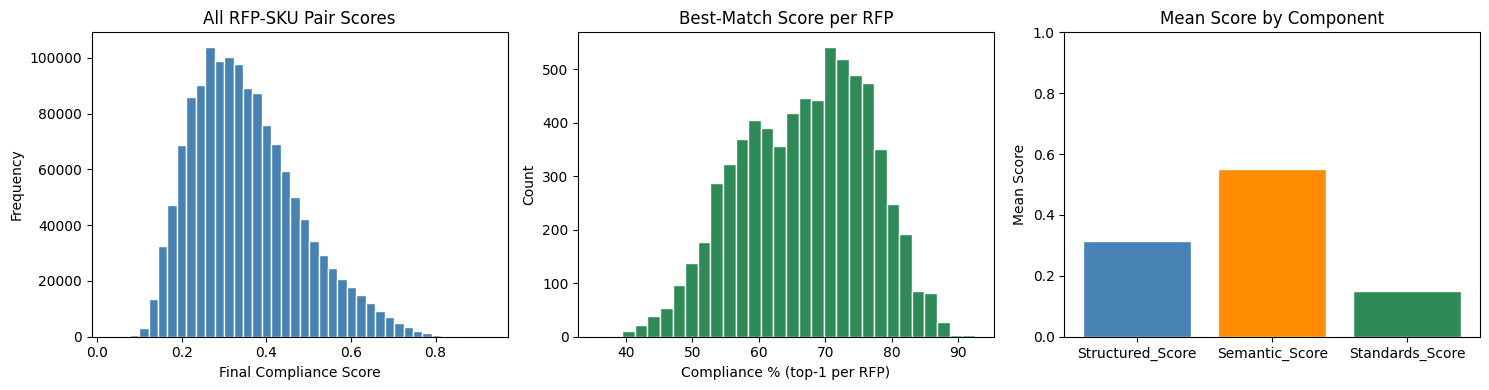

✅ Plot saved as compliance_distribution.png


In [ ]:
# ============================================================
# CELL 10 — VISUALISATION: COMPLIANCE SCORE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Overall compliance score distribution
axes[0].hist(match_df['Final_Compliance_Score'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('All RFP-SKU Pair Scores')
axes[0].set_xlabel('Final Compliance Score')
axes[0].set_ylabel('Frequency')

# 2. Best-match scores per RFP
axes[1].hist(best_matches['Compliance_%'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Best-Match Score per RFP')
axes[1].set_xlabel('Compliance % (top-1 per RFP)')
axes[1].set_ylabel('Count')

# 3. Score component breakdown (mean across all pairs)
comp_means = match_df[['Structured_Score','Semantic_Score','Standards_Score']].mean()
axes[2].bar(comp_means.index, comp_means.values,
            color=['steelblue','darkorange','seagreen'], edgecolor='white')
axes[2].set_title('Mean Score by Component')
axes[2].set_ylabel('Mean Score')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('compliance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as compliance_distribution.png")

In [ ]:
# ============================================================
# CELL 11 — EVALUATION METRICS FUNCTION  (FIX 7)
#
# Original: iterated match_df with boolean filter per RFP → O(N²)
# Fix: pre-group into dict of numpy arrays, O(N) total.
#
# Metrics computed:
#   Top-1 Accuracy  — correct SKU is rank-1
#   Top-K Accuracy  — correct SKU appears in top-K
#   Recall@K        — identical to Top-K for single-relevant setup
#   MRR             — Mean Reciprocal Rank
#   Precision@K     — hits / K
#   NDCG@K          — normalised discounted cumulative gain (added)
# ============================================================

def build_match_groups(
    match_df: pd.DataFrame,
    score_col: str = 'Final_Compliance_Score'
) -> Dict:
    """Pre-group match data by RFP into numpy arrays for fast metric computation."""
    groups = {}
    for rfp_id, grp in match_df.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'score':      grp[score_col].to_numpy(dtype=np.float32),
            'structured': grp['Structured_Score'].to_numpy(dtype=np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(dtype=np.float32),
            'standards':  grp['Standards_Score'].to_numpy(dtype=np.float32),
        }
    return groups


def calculate_metrics(
    match_groups: Dict,
    ground_truth_by_rfp: Dict,
    score_key: str = 'score',
    weights: Optional[Tuple] = None,
    K: int = 5
) -> Dict:
    """
    Compute retrieval metrics for a single model configuration.

    Parameters
    ----------
    match_groups        : output of build_match_groups()
    ground_truth_by_rfp : {rfp_id: ground_truth_sku}
    score_key           : which score array to rank by ('score', 'structured', …)
    weights             : if provided, recompute score = w_s*struct + w_e*sem + w_t*std
    K                   : cutoff for top-K metrics
    """
    top1 = 0; topk = 0; mrr_sum = 0.0; prec_sum = 0.0; ndcg_sum = 0.0
    evaluated = 0

    for rfp_id, group in match_groups.items():
        gt = ground_truth_by_rfp.get(rfp_id)
        if gt is None:
            continue

        sku_ids = group['sku_id']

        if weights is not None:
            ws, we, wt = weights
            scores = (ws * group['structured']
                    + we * group['semantic']
                    + wt * group['standards'])
        else:
            scores = group[score_key]

        # Descending sort by score, tie-break by SKU string ascending
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]

        # Ground-truth rank (1-based)
        gt_positions = np.where(ranked == gt)[0]
        if len(gt_positions) == 0:
            continue
        rank_pos = int(gt_positions[0]) + 1

        evaluated += 1

        if rank_pos == 1:
            top1 += 1
        if rank_pos <= K:
            topk += 1
            prec_sum  += 1.0 / K
            ndcg_sum  += 1.0 / np.log2(rank_pos + 1)   # ideal DCG also = 1/log2(2)

        mrr_sum += 1.0 / rank_pos

    if evaluated == 0:
        return {m: 0.0 for m in
                ['Top-1 Accuracy','Top-K Accuracy','Recall@K','MRR','Precision@K','NDCG@K']}

    ideal_ndcg = 1.0 / np.log2(2)   # ideal: GT at rank 1

    return {
        'Top-1 Accuracy': top1     / evaluated,
        'Top-K Accuracy': topk     / evaluated,
        'Recall@K':       topk     / evaluated,
        'MRR':            mrr_sum  / evaluated,
        'Precision@K':    prec_sum / evaluated,
        'NDCG@K':        (ndcg_sum / evaluated) / ideal_ndcg,
    }


print("✅ calculate_metrics() defined.")

✅ calculate_metrics() defined.


In [ ]:
# ============================================================
# CELL 12 — EVALUATE THREE MODELS
# ============================================================

K_value = 5

# Build ground-truth lookup
gt_lookup = (
    rfp_df[['rfp_id', 'ground_truth_sku']]
    .dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

# Build grouped arrays once
match_groups = build_match_groups(match_df)

# ── Model 1: Structured-only ──────────────────────────────
struct_metrics = calculate_metrics(
    match_groups, gt_lookup, score_key='structured', K=K_value
)

# ── Model 2: Semantic-only ────────────────────────────────
sem_metrics = calculate_metrics(
    match_groups, gt_lookup, score_key='semantic', K=K_value
)

# ── Model 3: Hybrid (0.5 / 0.3 / 0.2) ────────────────────
hybrid_metrics = calculate_metrics(
    match_groups, gt_lookup,
    weights=(0.5, 0.3, 0.2), K=K_value
)

comparison_df = pd.DataFrame([
    {'Model': 'Structured-only (w=1,0,0)',  **struct_metrics},
    {'Model': 'Semantic-only   (w=0,1,0)',  **sem_metrics},
    {'Model': 'Hybrid          (w=.5,.3,.2)', **hybrid_metrics},
])

print(f"\n{'='*70}")
print(f"  Model Comparison  (K={K_value}, N_RFPs={len(gt_lookup)})")
print(f"{'='*70}")
print(comparison_df.to_markdown(index=False, floatfmt='.4f'))


  Model Comparison  (K=5, N_RFPs=7000)
| Model                        |   Top-1 Accuracy |   Top-K Accuracy |   Recall@K |    MRR |   Precision@K |   NDCG@K |
|:-----------------------------|-----------------:|-----------------:|-----------:|-------:|--------------:|---------:|
| Structured-only (w=1,0,0)    |           0.0571 |           0.1753 |     0.1753 | 0.1295 |        0.0351 |   0.1168 |
| Semantic-only   (w=0,1,0)    |           0.1653 |           0.3354 |     0.3354 | 0.2610 |        0.0671 |   0.2484 |
| Hybrid          (w=.5,.3,.2) |           0.1781 |           0.4433 |     0.4433 | 0.3088 |        0.0887 |   0.3124 |


In [ ]:
# ============================================================
# CELL 13 — FULL ABLATION STUDY  (FIX 6)
#
# Original: only 4 hardcoded weight configs.
# Fix: full 66-combination grid at 0.1 steps where w_s+w_e+w_t=1.
# ============================================================

# Generate all valid weight triples summing to 1.0 at 0.1 steps
weight_configurations = []
for ws in np.arange(0.0, 1.01, 0.1):
    for we in np.arange(0.0, 1.01 - ws, 0.1):
        wt = round(1.0 - ws - we, 1)
        if wt >= -1e-9:
            weight_configurations.append(
                (round(ws, 1), round(we, 1), max(wt, 0.0))
            )
weight_configurations = sorted(set(weight_configurations))
print(f"Total weight configurations: {len(weight_configurations)}")

ablation_start = time.time()
ablation_rows  = []

for ws, we, wt in weight_configurations:
    m = calculate_metrics(
        match_groups, gt_lookup,
        weights=(ws, we, wt), K=K_value
    )
    ablation_rows.append({
        'Struct_W': ws, 'Sem_W': we, 'Std_W': wt, **m
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_end = time.time()
print(f"Ablation done in {ablation_end - ablation_start:.1f}s\n")

print(f"{'='*95}")
print("  Full Ablation Study Results")
print(f"{'='*95}")
print(ablation_df.to_markdown(index=False, floatfmt='.4f'))

Total weight configurations: 66
Ablation done in 21.1s

  Full Ablation Study Results
|   Struct_W |   Sem_W |   Std_W |   Top-1 Accuracy |   Top-K Accuracy |   Recall@K |    MRR |   Precision@K |   NDCG@K |
|-----------:|--------:|--------:|-----------------:|-----------------:|-----------:|-------:|--------------:|---------:|
|     0.0000 |  0.0000 |  1.0000 |           0.0466 |           0.0919 |     0.0919 | 0.0997 |        0.0184 |   0.0699 |
|     0.0000 |  0.1000 |  0.9000 |           0.4499 |           0.6900 |     0.6900 | 0.5605 |        0.1380 |   0.5687 |
|     0.0000 |  0.2000 |  0.8000 |           0.4499 |           0.6900 |     0.6900 | 0.5605 |        0.1380 |   0.5687 |
|     0.0000 |  0.3000 |  0.7000 |           0.4499 |           0.6900 |     0.6900 | 0.5605 |        0.1380 |   0.5687 |
|     0.0000 |  0.4000 |  0.6000 |           0.4499 |           0.6900 |     0.6900 | 0.5605 |        0.1380 |   0.5687 |
|     0.0000 |  0.5000 |  0.5000 |           0.4499 |       

In [ ]:
# ============================================================
# CELL 14 — ABLATION INSIGHTS
# ============================================================

best_top1 = ablation_df.loc[ablation_df['Top-1 Accuracy'].idxmax()]
best_mrr  = ablation_df.loc[ablation_df['MRR'].idxmax()]
best_ndcg = ablation_df.loc[ablation_df['NDCG@K'].idxmax()]

print("Best configuration by Top-1 Accuracy :")
print(f"  Weights (Struct/Sem/Std) = ({best_top1['Struct_W']:.1f}, {best_top1['Sem_W']:.1f}, {best_top1['Std_W']:.1f})"
      f"  →  Top-1 = {best_top1['Top-1 Accuracy']:.4f}")

print("\nBest configuration by MRR :")
print(f"  Weights (Struct/Sem/Std) = ({best_mrr['Struct_W']:.1f}, {best_mrr['Sem_W']:.1f}, {best_mrr['Std_W']:.1f})"
      f"  →  MRR = {best_mrr['MRR']:.4f}")

print("\nBest configuration by NDCG@K :")
print(f"  Weights (Struct/Sem/Std) = ({best_ndcg['Struct_W']:.1f}, {best_ndcg['Sem_W']:.1f}, {best_ndcg['Std_W']:.1f})"
      f"  →  NDCG@{K_value} = {best_ndcg['NDCG@K']:.4f}")

# Correlation analysis
for col in ['Struct_W', 'Sem_W', 'Std_W']:
    corr = ablation_df[col].corr(ablation_df['Top-1 Accuracy'])
    print(f"\n{col} vs Top-1 Accuracy correlation: {corr:+.3f}")

Best configuration by Top-1 Accuracy :
  Weights (Struct/Sem/Std) = (0.0, 0.1, 0.9)  →  Top-1 = 0.4499

Best configuration by MRR :
  Weights (Struct/Sem/Std) = (0.0, 0.1, 0.9)  →  MRR = 0.5605

Best configuration by NDCG@K :
  Weights (Struct/Sem/Std) = (0.0, 0.1, 0.9)  →  NDCG@5 = 0.5687

Struct_W vs Top-1 Accuracy correlation: -0.727

Sem_W vs Top-1 Accuracy correlation: +0.536

Std_W vs Top-1 Accuracy correlation: +0.191


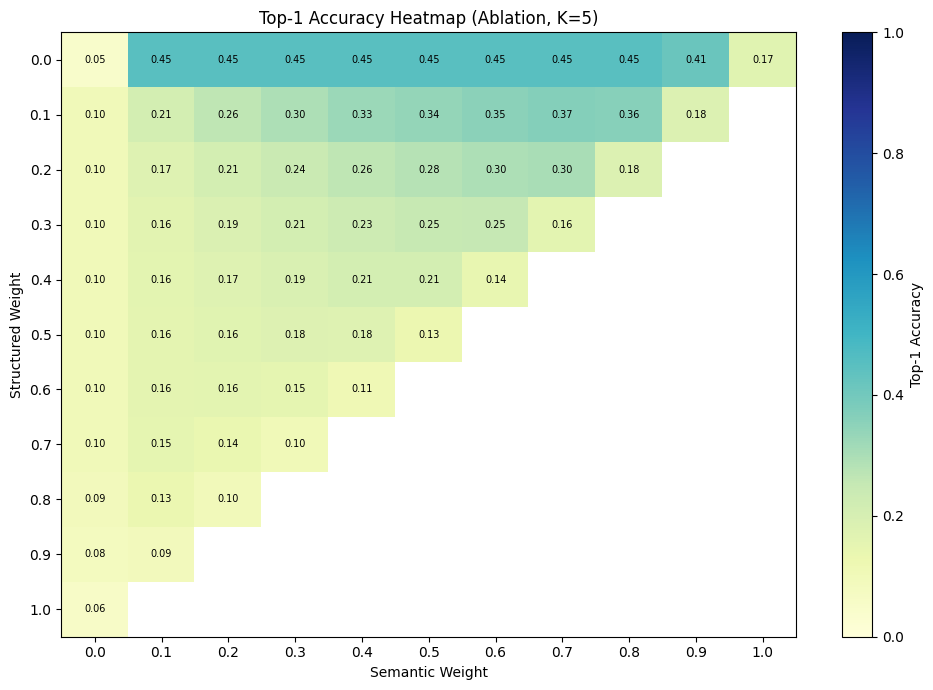

✅ Heatmap saved as ablation_heatmap.png


In [ ]:
# ============================================================
# CELL 15 — ABLATION HEATMAP
# ============================================================

pivot = ablation_df.pivot_table(
    values='Top-1 Accuracy',
    index='Struct_W',
    columns='Sem_W',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto',
               vmin=0, vmax=1)
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f'{v:.1f}' for v in pivot.columns])
ax.set_yticklabels([f'{v:.1f}' for v in pivot.index])
ax.set_xlabel('Semantic Weight')
ax.set_ylabel('Structured Weight')
ax.set_title(f'Top-1 Accuracy Heatmap (Ablation, K={K_value})')

for r in range(len(pivot.index)):
    for c in range(len(pivot.columns)):
        val = pivot.values[r, c]
        if not np.isnan(val):
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if val < 0.7 else 'white')

plt.colorbar(im, ax=ax, label='Top-1 Accuracy')
plt.tight_layout()
plt.savefig('ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved as ablation_heatmap.png")

In [ ]:
# ============================================================
# CELL 16 — EXPORT RESULTS
# ============================================================

best_matches.to_csv('top1_sku_per_rfp.csv', index=False)
ablation_df.to_csv('ablation_results.csv', index=False)
comparison_df.to_csv('model_comparison.csv', index=False)

print("✅ Exported:")
print("   top1_sku_per_rfp.csv   — best SKU per RFP with compliance scores")
print("   ablation_results.csv   — full 66-config ablation table")
print("   model_comparison.csv   — structured vs semantic vs hybrid comparison")

✅ Exported:
   top1_sku_per_rfp.csv   — best SKU per RFP with compliance scores
   ablation_results.csv   — full 66-config ablation table
   model_comparison.csv   — structured vs semantic vs hybrid comparison
